# LIME with Gaussian Neighbourhood Sampling

**Method:** Standard LIME (`LimeTabularExplainer`) with a modified neighbourhood
sampling strategy — only the sampling is replaced. Everything else (kernel,
Ridge surrogate, `explain_instance`, `as_pyplot_figure`) is unchanged LIME.

**The limitation we address** (Molnar 2022, Chapter 9):
> *Sampling could be improved in the current implementation of LIME.
> Data points are sampled from a Gaussian distribution, **ignoring the
> correlation between features**. This can lead to unlikely data points,
> which can then be used to learn local explanation models.*

**Our fix:** subclass `LimeTabularExplainer` and override only `__data_inverse`
(the sampling method) to draw from a **multivariate Gaussian** that respects
the training-data covariance structure:

$$\mathbf{z} \sim \mathcal{N}(\mathbf{x}_{\text{instance}},\; \widehat{\Sigma}_{\text{train}})$$

**References:**
- Ribeiro et al. (2016) — *Why Should I Trust You?*
- Molnar (2022) — *Interpretable Machine Learning*, Chapter 9
- Garreau & von Luxburg (2020) — *Looking Deeper into Tabular LIME*

## 1. Imports

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

import lime
import lime.lime_tabular

from pathlib import Path

DATA_PATH = Path("../../../outputs/outputs/all_matches_features_final.csv")
OUT_DIR   = Path("../../../thesis/figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load data and train XGBoost

In [43]:
# Feature list
FEATURES = [
    "distance_m",
    "angle_rad",
    "goal_diff",
    "time_since_last_event_s",
    "pressure_nd_dist_m",
    "pressure_def_count_r1m",
    "pressure_def_count_r2m",
    "obstruction_count",
    "gk_ball_distance",
    "gk_depth",
    "gk_lateral_offset",
    "ball_speed_mps",
    "shooter_speed_mps",
    "shot_body_part",
    "play_pattern",
]

# Load and clean data
df = pd.read_csv(DATA_PATH)
df["is_goal"] = pd.to_numeric(df["is_goal"], errors="coerce")
df = df.loc[df["is_goal"].isin([0, 1])].reset_index(drop=True)

feat_names = [f for f in FEATURES if f in df.columns]
print(f"Loaded {len(df)} shots — {int(df['is_goal'].sum())} goals — {len(feat_names)} features")

# Encode features — categorical columns label-encoded, rest cast to float
def encode(df_sub):
    X = df_sub.copy()
    for col in X.columns:
        if X[col].dtype == object or str(X[col].dtype) == "category":
            codes, _ = pd.factorize(X[col])
            X[col] = codes.astype(float)
            X.loc[X[col] == -1, col] = np.nan
        else:
            X[col] = pd.to_numeric(X[col], errors="coerce")
    return X.to_numpy(dtype=float)

X_raw = encode(df[feat_names])
y     = df["is_goal"].astype(int).to_numpy()

# Train/test split (stratified 80/20) + median imputation (no data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

train_medians = np.nanmedian(X_train, axis=0)
for j in range(X_train.shape[1]):
    X_train[np.isnan(X_train[:, j]), j] = train_medians[j]
    X_test[np.isnan(X_test[:, j]), j]   = train_medians[j]

# Train XGBoost — scale_pos_weight handles class imbalance (~88% non-goals)
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="logloss",
    random_state=42,
    verbosity=0,
)
model.fit(X_train, y_train)
print(f"XGBoost trained ✓  |  baseline xG = {y_train.mean():.3f}")

Loaded 4957 shots — 590 goals — 15 features
XGBoost trained ✓  |  baseline xG = 0.119


## 3. LIME with Gaussian Neighbourhood Sampling

Instance selected: median features shot
XGBoost prediction: xG = 0.1730

  distance_m                          16.018
  angle_rad                           0.371
  goal_diff                           0.000
  time_since_last_event_s             160.000
  pressure_nd_dist_m                  2.420
  pressure_def_count_r1m              0.000
  pressure_def_count_r2m              0.000
  obstruction_count                   1.000
  gk_ball_distance                    13.197
  gk_depth                            1.990
  gk_lateral_offset                   2.170
  ball_speed_mps                      13.463
  shooter_speed_mps                   2.305
  shot_body_part                      1.000
  play_pattern                        1.000

Surrogate fitted ✓
Surrogate R²    : 0.4355
Local prediction: 0.1398

Feature contributions (sorted by |coefficient|):
  pressure_nd_dist_m                       +0.0588
  shooter_speed_mps                        +0.0563
  gk_ball_distance                      

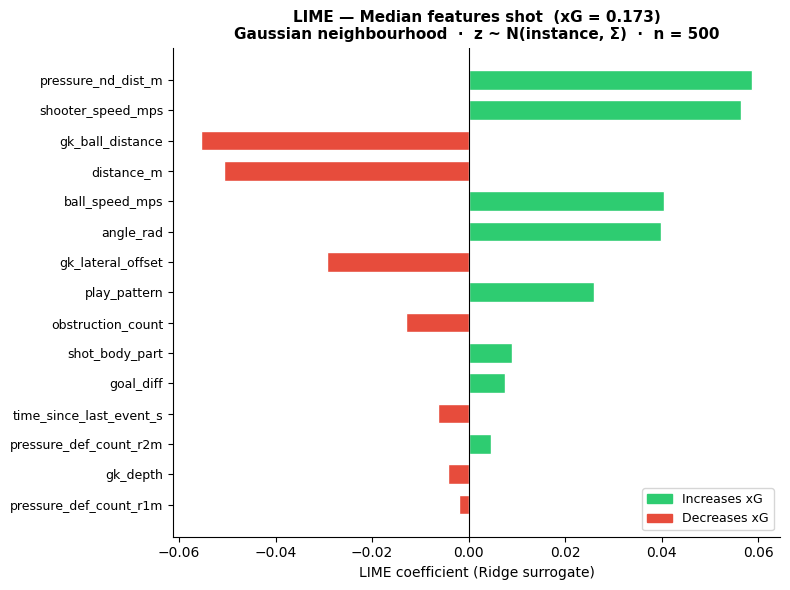


Saved → ../../../thesis/figures/lime_archetype_median.png


In [44]:
# ============================================================
# LIME with Gaussian neighbourhood sampling
# ============================================================
#
# We follow the 6-step LIME algorithm from the guide, with one
# modification: step 2 (generate samples) uses a multivariate
# Gaussian instead of independent per-feature sampling, so that
# correlations between features are respected.
#
# Standard LIME (guide):
#   Continuous  : X ~ N(μ, σ²)  independently per feature
#   Categorical : P(Y=j) = nⱼ/n
#
# Our modification:
#   Continuous  : z ~ N(instance, Cov(X_train) + εI)  ← correlated
#   Categorical : P(Y=j) = nⱼ/n                        ← unchanged
#
# The subclass below overrides only the sampling method.
# Everything else (kernel, surrogate, explain_instance) is LIME.
#

class GaussianLimeTabularExplainer(lime.lime_tabular.LimeTabularExplainer):
    """
    LimeTabularExplainer with correlated Gaussian sampling for continuous
    features and empirical distribution sampling for categorical features.
    """

    def __init__(self, training_data, categorical_feature_indices=None, **kwargs):
        super().__init__(training_data, **kwargs)

        self._cat_idx  = categorical_feature_indices or []
        self._cont_idx = [i for i in range(training_data.shape[1])
                          if i not in self._cat_idx]
        self._train    = training_data
        self._rng      = np.random.default_rng(42)

        # Covariance matrix from continuous training features.
        # ε = 1e-6 on diagonal ensures positive-definiteness.
        cont_data = training_data[:, self._cont_idx]
        self._cov = np.cov(cont_data.T) + 1e-6 * np.eye(len(self._cont_idx))

    def _LimeTabularExplainer__data_inverse(self, data_row, num_samples):
        """Step 2 — generate neighbourhood samples (called internally by LIME)."""
        n = num_samples - 1
        samples = np.zeros((n, len(data_row)))

        # Continuous features → multivariate Gaussian centred on the instance
        cont_instance = data_row[self._cont_idx]
        samples[:, self._cont_idx] = self._rng.multivariate_normal(
            mean=cont_instance, cov=self._cov, size=n
        )

        # Categorical features → empirical distribution P(Y=j) = nⱼ/n
        for idx in self._cat_idx:
            vals, counts = np.unique(self._train[:, idx], return_counts=True)
            probs = counts / counts.sum()
            samples[:, idx] = self._rng.choice(vals, size=n, p=probs)

        data = np.vstack([data_row, samples])   # data[0] = instance (LIME convention)
        return data, data.copy()


# ============================================================
# STEP 1 — SELECT THE INSTANCE TO EXPLAIN
# ============================================================

instance    = train_medians.copy()
xg_instance = float(model.predict_proba(instance.reshape(1, -1))[0, 1])

print(f"Instance selected: median features shot")
print(f"XGBoost prediction: xG = {xg_instance:.4f}")
print()
for name, val in zip(feat_names, instance):
    print(f"  {name:<35} {val:.3f}")


# ============================================================
# STEP 2 — GENERATE NEIGHBOURHOOD SAMPLES
# ============================================================

N_SAMPLES = 500

cat_indices = [feat_names.index(f)
               for f in ["shot_body_part", "play_pattern"]
               if f in feat_names]

explainer = GaussianLimeTabularExplainer(
    X_train,
    categorical_feature_indices=cat_indices,
    feature_names=feat_names,
    class_names=["no_goal", "goal"],
    discretize_continuous=False,
    mode="classification",
    random_state=42,
)


# ============================================================
# STEP 3 — ASSIGN A WEIGHT TO EACH SAMPLE (GAUSSIAN KERNEL)
# ============================================================
#
#   K(x, x') = exp( -||x - x'||² / σ² )
#   σ = 0.75 * sqrt(number of features)
#
# LIME applies this kernel automatically inside explain_instance.


# ============================================================
# STEP 4 — MAKE PREDICTIONS ON PERMUTATIONS
# ============================================================
#
# LIME calls model.predict_proba(neighbourhood) automatically.


# ============================================================
# STEP 5 — TRAIN A SURROGATE MODEL
# ============================================================

explanation = explainer.explain_instance(
    data_row        = instance,
    predict_fn      = model.predict_proba,
    labels          = (1,),
    num_features    = len(feat_names),
    num_samples     = N_SAMPLES,
    model_regressor = Ridge(alpha=0.01),
)

print(f"\nSurrogate fitted ✓")
print(f"Surrogate R²    : {explanation.score:.4f}")
print(f"Local prediction: {explanation.local_pred[0]:.4f}")


# ============================================================
# STEP 6 — INTERPRET THE SURROGATE MODEL
# ============================================================

print(f"\nFeature contributions (sorted by |coefficient|):")
for feat, coef in sorted(explanation.as_list(label=1), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:<40} {coef:+.4f}")

feat_coefs        = explanation.as_list(label=1)
feat_coefs_sorted = sorted(feat_coefs, key=lambda x: abs(x[1]))   # smallest at top

labels_plot = [f for f, _ in feat_coefs_sorted]   # raw feature names — same as SHAP figure
vals_plot   = [c for _, c in feat_coefs_sorted]
colors      = ["#2ecc71" if v > 0 else "#e74c3c" for v in vals_plot]

fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
ax.barh(range(len(labels_plot)), vals_plot, color=colors, edgecolor="white", height=0.65)
ax.set_yticks(range(len(labels_plot)))
ax.set_yticklabels(labels_plot, fontsize=9)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("LIME coefficient (Ridge surrogate)", fontsize=10)
ax.set_title(
    f"LIME — Median features shot  (xG = {xg_instance:.3f})\n"
    f"Gaussian neighbourhood  ·  z ~ N(instance, Σ)  ·  n = {N_SAMPLES}",
    fontsize=11, fontweight="bold"
)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(
    handles=[
        mpatches.Patch(color="#2ecc71", label="Increases xG"),
        mpatches.Patch(color="#e74c3c", label="Decreases xG"),
    ],
    fontsize=9, loc="lower right"
)
plt.tight_layout()
fig.savefig(OUT_DIR / "lime_archetype_median.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved → {OUT_DIR / 'lime_archetype_median.png'}")